In [1]:
import numpy as np
import numba
from numba import cuda
from time import time

In [2]:
cuda.detect()

Found 1 CUDA devices
id 0             b'Tesla T4'                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 4
                              PCI Bus ID: 0
                                    UUID: GPU-cd3aae26-5576-e4d8-122e-fe74181fea57
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 32
Summary:
	1/1 devices are supported


True

In [3]:
N = 100_000_000

a = np.random.rand(N).astype("float32")
b = np.random.rand(N).astype("float32")

result = np.empty(N, dtype="float32")

In [4]:
%timeit result = a + b

161 ms ± 18.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [5]:
@numba.njit(parallel=True)
def add(a, b, result):
  for i in numba.prange(a.shape[0]):
    result[i] = a[i] + b[i]

In [6]:
result = np.empty(N, dtype="float32")

%timeit add(a, b, result)

89.6 ms ± 1.19 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:

@cuda.jit
def add2(a, b, result):
  for i in range(a.shape[0]):
    result[i] = a[i] + b[i]

In [8]:
a2 = cuda.to_device(a)
b2 = cuda.to_device(b)
r2 = cuda.to_device(np.empty_like(result))

add2[1, 1](a2, b2, r2)
cuda.synchronize()

/usr/local/lib/python3.10/dist-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


In [9]:
%%timeit -n1 -r1

add2[1, 1](a2, b2, r2)
cuda.synchronize()

7.24 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [11]:
r2out = r2.copy_to_host()

In [12]:
np.allclose(result, r2out)

True

In [13]:
@cuda.jit
def add_better(a, b, result):

  idx = cuda.grid(1)
  if idx < a.shape[0]:
    result[idx] = a[idx] + b[idx]



In [15]:
import math
blockdim = 1024
griddim = int(math.ceil(a.shape[0]/blockdim))

N = 100_000_000

a = np.random.rand(N).astype("float32")
b = np.random.rand(N).astype("float32")

result = np.empty(N, dtype="float32")

a2 = cuda.to_device(a)
b2 = cuda.to_device(b)
r2 = cuda.to_device(np.empty_like(result))


add_better[griddim, blockdim](a2, b2, r2)

result_fromgpu = r2.copy_to_host()

print(result_fromgpu)

[0.6342811  1.4495282  0.6548326  ... 0.6094292  0.69943124 1.186256  ]


In [16]:
%%timeit -n1 -r1

add_better[griddim, blockdim](a2, b2, r2)
cuda.synchronize()

5.35 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [17]:
%%timeit

add_better[griddim, blockdim](a2, b2, r2)
cuda.synchronize()

4.75 ms ± 4.4 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [18]:
np.allclose(r2.copy_to_host(), result)

False

In [19]:
@cuda.jit(device=True)
def mandel(x, y, max_iters):
    """
    Given the real and imaginary parts of a complex number,
    determine if it is a candidate for membership in the Mandelbrot
    set given a fixed number of iterations.
    """
    i = 0
    c = complex(x,y)
    z = 0.0j
    for i in range(max_iters):
        z = z*z + c
        if (z.real*z.real + z.imag*z.imag) >= 4:
            return i

    return 255

Our previous example:

```python

def create_fractal(min_x, max_x, min_y, max_y, image, iters):
    height = image.shape[0]
    width = image.shape[1]

    pixel_size_x = (max_x - min_x) / width
    pixel_size_y = (max_y - min_y) / height
    for x in prange(width):
        real = min_x + x * pixel_size_x
        for y in range(height):
            imag = min_y + y * pixel_size_y
            color = mandel(real, imag, iters)
            image[y, x] = color
    return image
```

In [20]:
@cuda.jit
def create_fractal(min_x, max_x, min_y, max_y, image, iters):
    height = image.shape[0]
    width = image.shape[1]

    pixel_size_x = (max_x - min_x) / width
    pixel_size_y = (max_y - min_y) / height

    x, y = cuda.grid(2)

    if x < width and y < height:

      real = min_x + x * pixel_size_x
      imag = min_y + y * pixel_size_y
      color = mandel(real, imag, iters)
      image[y, x] = color

In [21]:
import math

image = np.zeros((2000, 3000), dtype=np.uint8)

im_gpu = cuda.to_device(image)


threadsperblock = (16, 16) # 16 * 16 = 256 threads
blockspergrid_x = math.ceil(im_gpu.shape[1] / threadsperblock[1])
blockspergrid_y = math.ceil(im_gpu.shape[0] / threadsperblock[0])
blockspergrid = (blockspergrid_x, blockspergrid_y)
create_fractal[blockspergrid, threadsperblock](-2.0, 1.0, -1.0, 1.0, im_gpu, 20)
cuda.synchronize()

Previous "best" one was 80 ms. Lets see How GPUs fair

In [22]:
%%timeit
create_fractal[blockspergrid, threadsperblock](-2.0, 1.0, -1.0, 1.0, im_gpu, 20)
cuda.synchronize()

5.87 ms ± 4.61 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


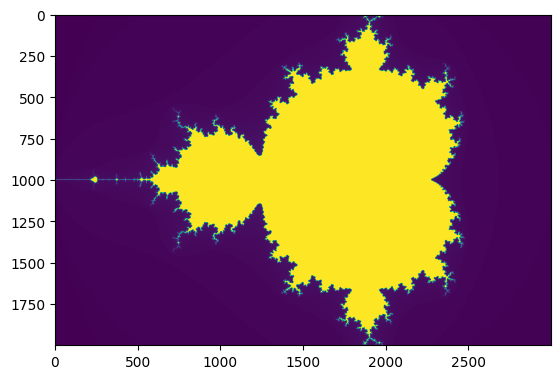

In [23]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(im_gpu.copy_to_host())
plt.show()